In [1]:
!pip install xgboost

In [2]:
!pip install prophet scikit-learn seaborn matplotlib

In [3]:
import pandas as pd
import numpy as np

# Mutlak yolunuzu kullanıyoruz
VERI_YOLU = r"C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\data\Amazon Sale Report.csv" 

# --- 1. VERİ YÜKLEME ---
try:
    # 'Amazon Sale Report' verisi bazen 'ISO-8859-1' veya 'latin-1' encoding ister
    df = pd.read_csv(VERI_YOLU, encoding='ISO-8859-1')
    print("✅ Ham Veri başarıyla yüklendi.")
except Exception as e:
    print(f"HATA: Veri yüklenirken hata oluştu: {e}")
    exit()

# --- 3. TEMİZLİK VE ZAMAN SERİSİ İÇİN DÖNÜŞÜM ---

# 3.1. Kritere Uymayan Satışları Filtreleme (Sadece Gerçekleşen Satışlar)
# Tahminimizi sadece başarıyla gönderilen veya teslim edilen satışlar üzerine kuruyoruz.
BASARILI_DURUMLAR = ['Shipped', 'Shipped - Delivered to Buyer', 'Delivered']
df = df[df['Status'].isin(BASARILI_DURUMLAR)].copy()
print("✅ Başarılı satışlar (Shipped/Delivered) filtrelendi.")

# 3.2. Kritik Sütunların Tipini Ayarlama
# Amount (Satış Miktarı/Geliri) sütununda eksik değerler olabilir.
df.dropna(subset=['Amount', 'Date'], inplace=True) 

# Amount sütununu sayısal (float) hale getirme
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df.dropna(subset=['Amount'], inplace=True) # Sayısala çevrilemeyenleri de atıyoruz.

# --- 4. HEDEF DEĞER (y) HESAPLAMA: GÜNLÜK TOPLAM GELİR ---

# 4.1. Tarih (ds) OLUŞTURMA VE DÖNÜŞÜM
# Tarih formatı 'MM-DD-YY' olduğu için bu formatı belirtmeliyiz.
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')
print("✅ 'Date' (Tarih) sütunu datetime formatına dönüştürüldü.")

# 4.2. Günlük Toplam Satışı Hesaplama (Zaman Serisi Formatı)
# Zaman serisi analizi için veriyi günlük bazda gruplayıp Amount (Gelir) toplamını alıyoruz.
df_ts = df.groupby(df['Date'].dt.date)['Amount'].sum().reset_index()

# Sütun adlarını zaman serisi kütüphanelerinin istediği formata çevirme (ds ve y)
df_ts.rename(columns={'Date': 'ds', 'Amount': 'y'}, inplace=True)

# ds sütununu tekrar datetime olarak ayarla
df_ts['ds'] = pd.to_datetime(df_ts['ds'])

print("\n" + "="*70)
print("       ZAMAN SERİSİ İÇİN HAZIRLANMIŞ VERİ (df_ts)")
print("="*70)
print(f"Toplam Gün Sayısı: {len(df_ts)}")
print(f"Başlangıç Tarihi: {df_ts['ds'].min()}")
print(f"Bitiş Tarihi: {df_ts['ds'].max()}")
print("\nİlk 5 Satır:")
print(df_ts.head())

# İleride kullanmak üzere nihai veriyi kaydet
# Eğer data klasörünüzde değilse, yolu kontrol edin:
# df_ts.to_csv(r'C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\data\temiz_gunluk_satis_verisi.csv', index=False)

C:\Users\ozlem\AppData\Local\Temp\ipykernel_18464\2152942398.py:10: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(VERI_YOLU, encoding='ISO-8859-1')


✅ Ham Veri başarıyla yüklendi.
✅ Başarılı satışlar (Shipped/Delivered) filtrelendi.
✅ 'Date' (Tarih) sütunu datetime formatına dönüştürüldü.

       ZAMAN SERİSİ İÇİN HAZIRLANMIŞ VERİ (df_ts)
Toplam Gün Sayısı: 91
Başlangıç Tarihi: 2022-03-31 00:00:00
Bitiş Tarihi: 2022-06-29 00:00:00

İlk 5 Satır:
          ds         y
0 2022-03-31   94183.0
1 2022-04-01  767000.0
2 2022-04-02  804455.0
3 2022-04-03  911517.0
4 2022-04-04  802266.0


Importing plotly failed. Interactive plots will not work.
21:07:51 - cmdstanpy - INFO - Chain [1] start processing
21:07:52 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet Modeli Başarıyla Eğitildi.
✅ Gelecek 7 günlük tahmin çerçevesi oluşturuldu.

     PROPHET MODELİ PERFORMANS METRİKLERİ
MAE (Ortalama Mutlak Hata): 286,287.23 INR
RMSE (Kök Ortalama Kare Hata): 319,775.43 INR


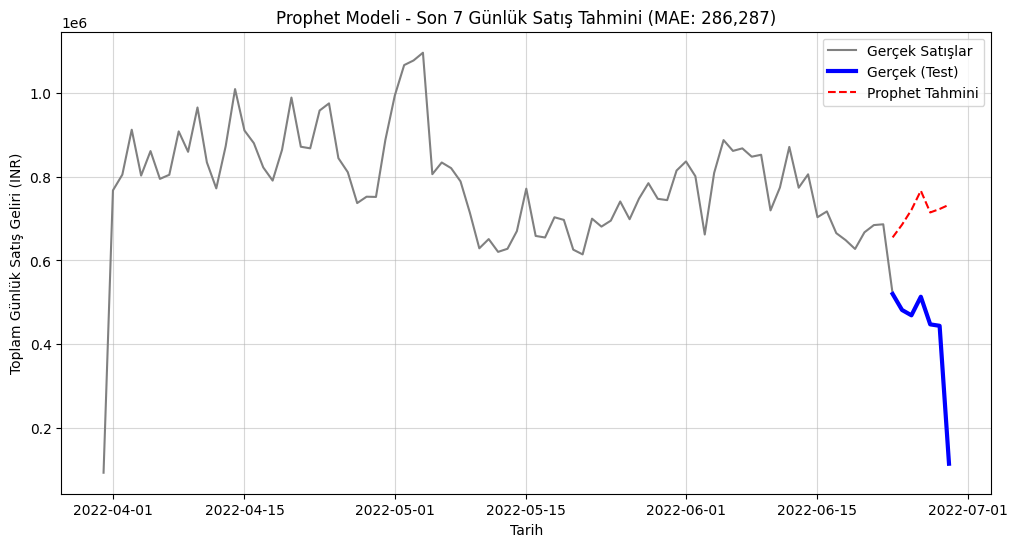


✅ Prophet tahmini tamamlandı ve görsel kaydedildi.


In [4]:
# Gerekli kütüphaneleri yükleme (Prophet, scikit-learn ve diğerleri)
# Eğer kurulu değilse, yeni bir hücrede !pip install prophet scikit-learn seaborn matplotlib yazıp çalıştırın!
import os # Kaydetmek için bu kritik!
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. VERİ BÖLÜMLEME ---

TATIL_GUNU_SAYISI = 7 
df_train = df_ts.iloc[:-TATIL_GUNU_SAYISI]
df_test = df_ts.iloc[-TATIL_GUNU_SAYISI:]

# --- 2. PROPHET MODELİ EĞİTİMİ ---

m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False
)

m.fit(df_train)
print("✅ Prophet Modeli Başarıyla Eğitildi.")

# --- 3. TAHMİN ÇERÇEVESİ OLUŞTURMA ---

future = m.make_future_dataframe(periods=TATIL_GUNU_SAYISI, include_history=False)
print(f"✅ Gelecek {TATIL_GUNU_SAYISI} günlük tahmin çerçevesi oluşturuldu.")
forecast = m.predict(future)

# --- 4. MODEL PERFORMANSI VE GÖRSELLEŞTİRME ---

y_pred_prophet = forecast['yhat'].values
y_true = df_test['y'].values

mae_prophet = mean_absolute_error(y_true, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred_prophet))

print("\n" + "="*50)
print("     PROPHET MODELİ PERFORMANS METRİKLERİ")
print("="*50)
print(f"MAE (Ortalama Mutlak Hata): {mae_prophet:,.2f} INR")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse_prophet:,.2f} INR")

# Tahminleri görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df_ts['ds'], df_ts['y'], label='Gerçek Satışlar', color='gray')
plt.plot(df_test['ds'], y_true, label='Gerçek (Test)', color='blue', linewidth=3)
plt.plot(df_test['ds'], y_pred_prophet, label='Prophet Tahmini', color='red', linestyle='--')
plt.title(f'Prophet Modeli - Son {TATIL_GUNU_SAYISI} Günlük Satış Tahmini (MAE: {mae_prophet:,.0f})')
plt.xlabel('Tarih')
plt.ylabel('Toplam Günlük Satış Geliri (INR)')
plt.legend()
plt.grid(True, alpha=0.5)

# Görseli kaydet
FIGURES_YOLU = r'C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\figures'
os.makedirs(FIGURES_YOLU, exist_ok=True)
plt.savefig(os.path.join(FIGURES_YOLU, 'prophet_tahmini.png'))
plt.show()

print("\n✅ Prophet tahmini tamamlandı ve görsel kaydedildi.")


✅ Zaman bazlı özellikler başarıyla oluşturuldu.

Özellik Mühendisliği Yapılmış Veri Seti (İlk 5 Satır):
          ds         y  dayofweek  dayofyear  weekofyear  month  year  \
1 2022-04-01  767000.0          4         91          13      4  2022   
2 2022-04-02  804455.0          5         92          13      4  2022   
3 2022-04-03  911517.0          6         93          13      4  2022   
4 2022-04-04  802266.0          0         94          14      4  2022   
5 2022-04-05  860601.0          1         95          14      4  2022   

      lag_1  
1   94183.0  
2  767000.0  
3  804455.0  
4  911517.0  
5  802266.0  

✅ XGBoost Modeli Başarıyla Eğitildi.

     XGBOOST MODELİ PERFORMANS METRİKLERİ
MAE (Ortalama Mutlak Hata): 233,289.27 INR
RMSE (Kök Ortalama Kare Hata): 271,363.48 INR


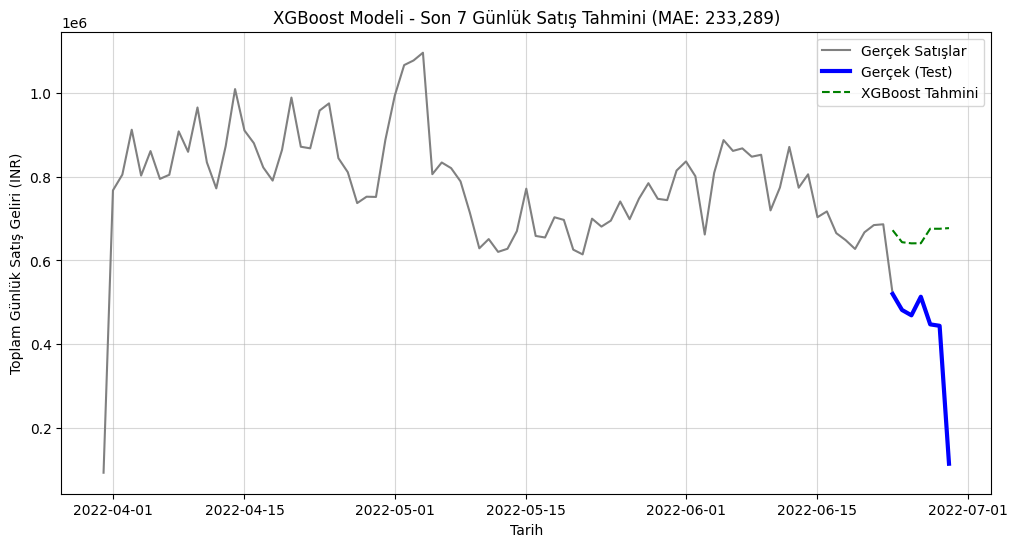


⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡ MODEL KARŞILAŞTIRMA ÖZETİ ⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡
Prophet MAE: 286,287.23 INR
XGBoost MAE: 233,289.27 INR

✅ XGBoost tahmini tamamlandı ve görsel kaydedildi.


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os # Kaydetmek için

# df_ts DataFrame'imiz hazır olmalı.

# --- 1. ZAMAN BAZLI ÖZELLİK MÜHENDİSLİĞİ (Feature Engineering) ---
def create_features(df):
    """Zaman serisi verisinden regresyon için özellikler çıkarır."""
    df['dayofweek'] = df['ds'].dt.dayofweek # Haftanın günü (0=Pazartesi, 6=Pazar)
    df['dayofyear'] = df['ds'].dt.dayofyear # Yılın kaçıncı günü
    df['weekofyear'] = df['ds'].dt.isocalendar().week.astype(int) # Yılın kaçıncı haftası
    df['month'] = df['ds'].dt.month # Ay
    df['year'] = df['ds'].dt.year # Yıl
    
    # Hedef değer (y) bir gün öncesinden ne kadar etkilendi? (Lag Feature)
    # Bu, zaman serilerinde kritik bir özelliktir.
    df['lag_1'] = df['y'].shift(1)
    
    # Eksik değerleri (ilk satırdaki lag_1) ortalama ile doldurma
    df.dropna(inplace=True) 
    return df

df_ml = create_features(df_ts.copy())

print("✅ Zaman bazlı özellikler başarıyla oluşturuldu.")
print("\nÖzellik Mühendisliği Yapılmış Veri Seti (İlk 5 Satır):")
print(df_ml.head())

# --- 2. VERİ BÖLÜMLEME (ML İÇİN) ---

# Özellikler (X) ve Hedef (y) belirleme
FEATURES = ['dayofweek', 'dayofyear', 'weekofyear', 'month', 'year', 'lag_1']
TARGET = 'y'

X = df_ml[FEATURES]
y = df_ml[TARGET]

# Veriyi ayırma: Son 7 günü test olarak kullanmaya devam ediyoruz
X_train = X.iloc[:-7]
X_test = X.iloc[-7:]
y_train = y.iloc[:-7]
y_test = y.iloc[-7:]

# --- 3. XGBOOST MODELİ EĞİTİMİ ---

model_xgb = XGBRegressor(n_estimators=1000, 
                         early_stopping_rounds=10, 
                         learning_rate=0.01,
                         random_state=42)

model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("\n✅ XGBoost Modeli Başarıyla Eğitildi.")

# --- 4. TAHMİN VE PERFORMANS ---

y_pred_xgb = model_xgb.predict(X_test)

# Hata metriklerini hesaplama
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\n" + "="*50)
print("     XGBOOST MODELİ PERFORMANS METRİKLERİ")
print("="*50)
print(f"MAE (Ortalama Mutlak Hata): {mae_xgb:,.2f} INR")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse_xgb:,.2f} INR")

# --- 5. SONUÇLARI KARŞILAŞTIRMA VE GÖRSELLEŞTİRME ---

# XGBoost sonuçlarını görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df_ts['ds'], df_ts['y'], label='Gerçek Satışlar', color='gray') # Tüm seri
plt.plot(df_test['ds'], y_test, label='Gerçek (Test)', color='blue', linewidth=3)
plt.plot(df_test['ds'], y_pred_xgb, label='XGBoost Tahmini', color='green', linestyle='--')
plt.title(f'XGBoost Modeli - Son 7 Günlük Satış Tahmini (MAE: {mae_xgb:,.0f})')
plt.xlabel('Tarih')
plt.ylabel('Toplam Günlük Satış Geliri (INR)')
plt.legend()
plt.grid(True, alpha=0.5)

# Görseli kaydet
FIGURES_YOLU = r'C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\figures'
plt.savefig(os.path.join(FIGURES_YOLU, 'xgboost_tahmini.png'))
plt.show()

# --- 6. KARŞILAŞTIRMA ÖZETİ ---
print("\n" + "⚡"*10 + " MODEL KARŞILAŞTIRMA ÖZETİ " + "⚡"*10)
print(f"Prophet MAE: {mae_prophet:,.2f} INR")
print(f"XGBoost MAE: {mae_xgb:,.2f} INR")

print("\n✅ XGBoost tahmini tamamlandı ve görsel kaydedildi.")

In [6]:
import pandas as pd
import os

# --- 1. PROPHET VE XGBOOST SONUÇLARINI BİRLEŞTİRME ---

# Prophet tahmini (sadece yhat)
df_prophet_preds = pd.DataFrame({
    'ds': df_test['ds'],
    'Prophet_Pred': y_pred_prophet
})

# XGBoost tahmini (sadece yhat)
df_xgb_preds = pd.DataFrame({
    'ds': df_test['ds'],
    'XGBoost_Pred': y_pred_xgb
})

# Gerçek değerler (y)
df_gercek = df_test[['ds', 'y']].rename(columns={'y': 'Gerçek_Satış'})

# Tüm verileri ds sütununa göre birleştirme
df_final_karsilastirma = df_gercek.merge(df_prophet_preds, on='ds', how='left')
df_final_karsilastirma = df_final_karsilastirma.merge(df_xgb_preds, on='ds', how='left')

print("✅ Tahmin sonuçları tek bir DataFrame'de birleştirildi.")
print("\nSon 7 Günlük Tahmin Özeti:")
print(df_final_karsilastirma)

# --- 2. DASHBOARD İÇİN CSV OLARAK KAYDETME ---

DASHBOARD_VERI_YOLU = r'C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\data\dashboard_verisi.csv'
df_final_karsilastirma.to_csv(DASHBOARD_VERI_YOLU, index=False)
print(f"\n✅ Sonuçlar dashboard hazırlığı için kaydedildi: {DASHBOARD_VERI_YOLU}")

✅ Tahmin sonuçları tek bir DataFrame'de birleştirildi.

Son 7 Günlük Tahmin Özeti:
          ds  Gerçek_Satış   Prophet_Pred  XGBoost_Pred
0 2022-06-23      520139.0  654937.416342   672051.9375
1 2022-06-24      481957.0  685214.131842   643462.4375
2 2022-06-25      469255.0  720473.643266   640765.3750
3 2022-06-26      513518.0  766203.282301   641029.2500
4 2022-06-27      447699.0  714354.220728   675600.7500
5 2022-06-28      444275.0  722595.256125   675513.5625
6 2022-06-29      115595.0  732670.659810   677039.5625

✅ Sonuçlar dashboard hazırlığı için kaydedildi: C:\Users\ozlem\OneDrive\Belgeler\GitHub\e-ticaret-satis-tahmini\data\dashboard_verisi.csv
